In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Base path — all project files sit under this folder in your Drive
BASE = "/content/drive/MyDrive/code_review_project"

print(f"Base path: {BASE}")
print("Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base path: /content/drive/MyDrive/code_review_project
Drive mounted successfully.


# Notebook 03: Model Training

**Project:** Intelligent Code Review Assistant  
**Notebook:** 03 of 04  
**Input:** `../data/processed/train.pt`, `val.pt`, `test.pt`, `class_weights.npy`, `preprocessing_config.pkl`  
**Output:** `../models/codebert_classifier/` (fine-tuned model), `../reports/training_results.pkl`

---

## Objectives
- Load the tokenized splits produced by Notebook 02
- Build a CodeBERT-based binary classifier (buggy vs clean)
- Fine-tune with weighted cross-entropy loss to handle class imbalance
- Train with early stopping to avoid overfitting
- Evaluate on the held-out test set (accuracy, precision, recall, F1, ROC-AUC)
- Save the trained model and all results for Notebook 04

---

## Pipeline
```
train.pt / val.pt / test.pt
        ↓
Load CodeBERT + add classification head
        ↓
Training loop (weighted loss + early stopping)
        ↓
Validation each epoch -> save best checkpoint
        ↓
Final evaluation on test set
        ↓
Save model -> ../models/codebert_classifier/
Save results -> ../reports/training_results.pkl
```

### Install dependencies

In [8]:
# Install libraries needed for this notebook.
# Run once, then restart kernel if needed.

!pip install transformers torch scikit-learn pandas numpy tqdm matplotlib seaborn -q

---
## Section 1: Imports & Configuration

In [9]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

# ── Data handling ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── PyTorch ────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace Transformers ───────────────────────────────────────────────────
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

# ── Scikit-learn metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Progress bar ───────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

# ── Styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries imported successfully.")

All libraries imported successfully.


In [10]:
# ── Central config ─────────────────────────────────────────────────────────────
#
# EPOCHS        : Maximum training epochs. Early stopping usually kicks in before this.
# LEARNING_RATE : 2e-5 is the standard starting LR for fine-tuning BERT-scale models.
#                 Too high (>5e-5) causes catastrophic forgetting of pre-trained weights.
#                 Too low (<1e-5) makes training extremely slow.
# WARMUP_RATIO  : Fraction of total steps used for LR warmup.
#                 LR linearly increases from 0 -> LR during warmup, then linearly decays.
# PATIENCE      : Early stopping — stop if val F1 does not improve for this many epochs.
# FREEZE_LAYERS : Number of CodeBERT encoder layers to freeze (bottom N of 12).
#                 Frozen layers are not updated during training — cuts training time ~60%.
#                 Top layers (12 - FREEZE_LAYERS) + classifier head are trained.

CONFIG = {
    "MODEL_NAME"      : "microsoft/codebert-base",
    "MAX_LENGTH"      : 512,   # <- full length, safe on T4
    "BATCH_SIZE"      : 16,    # <- fine on T4 with 512
    "GRAD_ACCUM_STEPS": 2,     # <- simulates batch 32
    "EPOCHS"          : 10,
    "LEARNING_RATE"   : 2e-5,
    "WARMUP_RATIO"    : 0.1,
    "PATIENCE"        : 3,
    "FREEZE_LAYERS"   : 6,     # <- unfreeze more since GPU handles it
    "DROPOUT"         : 0.1,
    "DATA_DIR"        : f"{BASE}/data/processed/",
    "MODEL_SAVE_DIR"  : f"{BASE}/models/codebert_classifier/",
    "TOKENIZER_DIR"   : f"{BASE}/models/tokenizer/",
    "REPORTS_DIR"     : f"{BASE}/reports/",
}

# ── Detect device ──────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["DEVICE"] = str(DEVICE)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"   {k:<18}: {v}")
print(f"\n   Device : {DEVICE}")
if str(DEVICE) == "cpu":
    print("   No GPU detected. Fine-tuning CodeBERT on CPU will be very slow.")
    print("   Consider: Google Colab -> Runtime -> Change runtime type -> GPU.")

Configuration:
   MODEL_NAME        : microsoft/codebert-base
   MAX_LENGTH        : 512
   BATCH_SIZE        : 16
   GRAD_ACCUM_STEPS  : 2
   EPOCHS            : 10
   LEARNING_RATE     : 2e-05
   WARMUP_RATIO      : 0.1
   PATIENCE          : 3
   FREEZE_LAYERS     : 6
   DROPOUT           : 0.1
   DATA_DIR          : /content/drive/MyDrive/code_review_project/data/processed/
   MODEL_SAVE_DIR    : /content/drive/MyDrive/code_review_project/models/codebert_classifier/
   TOKENIZER_DIR     : /content/drive/MyDrive/code_review_project/models/tokenizer/
   REPORTS_DIR       : /content/drive/MyDrive/code_review_project/reports/
   DEVICE            : cuda

   Device : cuda


---
## Section 2: Load Data from Notebook 02

Load the tokenized tensor splits and preprocessing config saved at the end of Notebook 02.  
The `CodeDataset` class is re-defined here so `DataLoader` can wrap the tensors correctly.

In [11]:
# Re-define CodeDataset here so DataLoader works correctly in this notebook.
# The tensors were saved as plain dicts in Notebook 02 (not full Dataset objects),
# so we reconstruct the Dataset from those dicts below.

class CodeDataset(Dataset):
    """
    PyTorch Dataset for tokenized code classification.
    Accepts either a dict of tensors (from torch.load) or pre-built tensors.
    """
    def __init__(self, data: dict):
        self.input_ids      = data["input_ids"]
        self.attention_mask = data["attention_mask"]
        self.labels         = data["labels"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx]
        }

    def get_label_distribution(self):
        labels = self.labels.numpy()
        unique, counts = np.unique(labels, return_counts=True)
        return dict(zip(unique, counts))

print("CodeDataset class defined.")

CodeDataset class defined.


In [12]:
# Load preprocessing config saved by Notebook 02.
# This ensures we use identical model name, batch size, and class weights
# without manually matching values across notebooks.

config_path = os.path.join(CONFIG["DATA_DIR"], "preprocessing_config.pkl")
with open(config_path, "rb") as f:
    prep_config = pickle.load(f)

print("Preprocessing config loaded:")
for k, v in prep_config.items():
    print(f"   {k:<18}: {v}")

# Load class weights (computed from train split only in Notebook 02)
class_weights = np.load(os.path.join(CONFIG["DATA_DIR"], "class_weights.npy"))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"\nClass weights: {class_weights}")
print(f"   Class 0 (clean): {class_weights[0]:.4f}")
print(f"   Class 1 (buggy): {class_weights[1]:.4f}")

Preprocessing config loaded:
   model_name        : microsoft/codebert-base
   max_length        : 512
   batch_size        : 16
   random_state      : 42
   num_labels        : 2
   train_size        : 27758
   val_size          : 5949
   test_size         : 5949
   class_weights     : [0.6988418932527694, 1.7572803241326918]
   label_map         : {0: 'clean', 1: 'buggy'}

Class weights: [0.69884189 1.75728032]
   Class 0 (clean): 0.6988
   Class 1 (buggy): 1.7573


In [13]:
# Load the three tokenized splits saved by Notebook 02.
# Each .pt file contains a dict with keys: input_ids, attention_mask, labels.

print("Loading tokenized splits...")

train_data = torch.load(os.path.join(CONFIG["DATA_DIR"], "train.pt"), weights_only=True)
val_data   = torch.load(os.path.join(CONFIG["DATA_DIR"], "val.pt"),   weights_only=True)
test_data  = torch.load(os.path.join(CONFIG["DATA_DIR"], "test.pt"),  weights_only=True)

train_dataset = CodeDataset(train_data)
val_dataset   = CodeDataset(val_data)
test_dataset  = CodeDataset(test_data)

print(f"\n{'Split':<10} {'Samples':>10} {'Clean (0)':>12} {'Buggy (1)':>12}")
print("─" * 46)
for name, ds in [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]:
    dist  = ds.get_label_distribution()
    clean = dist.get(0, 0)
    buggy = dist.get(1, 0)
    print(f"{name:<10} {len(ds):>10,} {clean:>12,} {buggy:>12,}")

Loading tokenized splits...

Split         Samples    Clean (0)    Buggy (1)
──────────────────────────────────────────────
Train          27,758       19,860        7,898
Val             5,949        4,256        1,693
Test            5,949        4,256        1,693


In [14]:
# Build DataLoaders for all three splits.
# Train loader shuffles every epoch; val and test loaders do not.

NUM_WORKERS = 0   # 0 is safe on all platforms for small datasets
use_pin_memory = (str(DEVICE) == "cuda")

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=use_pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=use_pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=use_pin_memory
)

print("DataLoaders created.")
print(f"\n{'Split':<10} {'Samples':>10} {'Batches':>10} {'Batch size':>12}")
print("─" * 44)
for name, loader in [("Train", train_loader), ("Val", val_loader), ("Test", test_loader)]:
    print(f"{name:<10} {len(loader.dataset):>10,} {len(loader):>10,} {CONFIG['BATCH_SIZE']:>12}")

# Verify one batch
batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"   input_ids      : {batch['input_ids'].shape}")
print(f"   attention_mask : {batch['attention_mask'].shape}")
print(f"   labels         : {batch['labels'].shape}")

DataLoaders created.

Split         Samples    Batches   Batch size
────────────────────────────────────────────
Train          27,758      1,735           16
Val             5,949        372           16
Test            5,949        372           16

Sample batch shapes:
   input_ids      : torch.Size([16, 512])
   attention_mask : torch.Size([16, 512])
   labels         : torch.Size([16])


---
## Section 3: Model Architecture

The classifier is built on top of `microsoft/codebert-base` (a RoBERTa-style transformer  
pre-trained on code from 6 languages).

**Architecture:**

```
Input tokens (512)
↓
CodeBERT encoder (12 transformer layers)
↓
[CLS] token hidden state (768-dim)
↓
Dropout (0.1)
↓
Linear layer (768 -> 2)
↓
Logits -> CrossEntropyLoss
```
The bottom `FREEZE_LAYERS` (6 of 12) encoder layers are frozen — their weights  
are not updated during training. Only the top 6 layers and the classifier head are trained.  
This cuts training time by ~60% and reduces the risk of overfitting on small datasets.

In [15]:
class CodeBERTClassifier(nn.Module):
    """
    Binary classifier built on top of CodeBERT.

    Architecture:
        CodeBERT encoder → [CLS] hidden state → Dropout → Linear(768, num_labels)

    Parameters
    ----------
    model_name   : HuggingFace model ID (e.g. 'microsoft/codebert-base')
    num_labels   : Number of output classes (2 for binary classification)
    dropout      : Dropout probability applied before the classification head
    freeze_layers: Number of encoder layers to freeze (bottom N of 12)
    """

    def __init__(
        self,
        model_name: str   = "microsoft/codebert-base",
        num_labels: int   = 2,
        dropout: float    = 0.1,
        freeze_layers: int = 6
    ):
        super().__init__()

        # Load the pre-trained CodeBERT encoder (no classification head)
        self.encoder = AutoModel.from_pretrained(model_name)

        # Dropout applied to [CLS] representation before classification
        self.dropout = nn.Dropout(dropout)

        # Classification head: maps 768-dim [CLS] vector → num_labels logits
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_labels)

        # Freeze the bottom `freeze_layers` encoder layers
        self._freeze_encoder_layers(freeze_layers)

    def _freeze_encoder_layers(self, n: int):
        """Freeze the bottom n transformer encoder layers."""
        # Always freeze the embedding layer
        for param in self.encoder.embeddings.parameters():
            param.requires_grad = False

        # Freeze the bottom n encoder layers
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < n:
                for param in layer.parameters():
                    param.requires_grad = False

        # Count trainable vs frozen params for reporting
        total  = sum(p.numel() for p in self.parameters())
        frozen = sum(p.numel() for p in self.parameters() if not p.requires_grad)
        print(f"   Total parameters    : {total:,}")
        print(f"   Frozen parameters   : {frozen:,}  (bottom {n} encoder layers + embeddings)")
        print(f"   Trainable parameters: {total - frozen:,}  (top {12 - n} encoder layers + head)")

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass.

        Returns a dict with:
            'loss'   — CrossEntropyLoss (only if labels are provided)
            'logits' — raw output scores, shape (batch_size, num_labels)
        """
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # outputs.last_hidden_state: (batch, seq_len, hidden_size)
        # Take the [CLS] token (position 0) as the sequence representation
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch, 768)

        cls_output = self.dropout(cls_output)
        logits     = self.classifier(cls_output)           # (batch, 2)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


print("CodeBERTClassifier class defined.")

CodeBERTClassifier class defined.


In [16]:
# Instantiate the model and move to the available device (GPU or CPU).

print(f"Loading base model: {CONFIG['MODEL_NAME']}")
print(f"Freezing bottom {CONFIG['FREEZE_LAYERS']} of 12 encoder layers...\n")

model = CodeBERTClassifier(
    model_name    = CONFIG["MODEL_NAME"],
    num_labels    = prep_config["num_labels"],
    dropout       = CONFIG["DROPOUT"],
    freeze_layers = CONFIG["FREEZE_LAYERS"]
)

model = model.to(DEVICE)

print(f"\nModel moved to: {DEVICE}")

Loading base model: microsoft/codebert-base
Freezing bottom 6 of 12 encoder layers...



config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

   Total parameters    : 124,647,170
   Frozen parameters   : 81,527,808  (bottom 6 encoder layers + embeddings)
   Trainable parameters: 43,119,362  (top 6 encoder layers + head)

Model moved to: cuda


---
## Section 4: Optimizer, Scheduler & Loss Function

| Component | Choice | Reason |
|---|---|---|
| Optimizer | AdamW | Standard for transformer fine-tuning; decoupled weight decay |
| Scheduler | Linear warmup + decay | Prevents large gradient updates early in training |
| Loss | Weighted CrossEntropyLoss | Penalizes misclassifying the minority (buggy) class more |

The class weights computed in Notebook 02 are passed directly to `CrossEntropyLoss`.  
This means every buggy sample contributes proportionally more to the loss than a clean sample.

In [17]:
from torch.optim import AdamW

# ── Optimizer ──────────────────────────────────────────────────────────────────
# Only optimize parameters that require gradients (i.e. unfrozen layers + head).
# weight_decay applies L2 regularization to prevent overfitting.
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["LEARNING_RATE"],
    weight_decay=0.01
)

# ── Steps calculation ──────────────────────────────────────────────────────────
total_steps  = len(train_loader) * CONFIG["EPOCHS"]
warmup_steps = int(total_steps * CONFIG["WARMUP_RATIO"])

# ── Scheduler ─────────────────────────────────────────────────────────────────
# LR linearly increases 0 → LR during warmup, then linearly decays to 0.
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

# ── Weighted loss function ─────────────────────────────────────────────────────
# class_weights_tensor was built from class_weights loaded from Notebook 02.
# Weight for class 1 (buggy) > weight for class 0 (clean) because buggy is minority.
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Optimizer, scheduler, and loss function ready.")
print(f"\n   Total training steps : {total_steps:,}")
print(f"   Warmup steps         : {warmup_steps:,}  ({CONFIG['WARMUP_RATIO']*100:.0f}% of total)")
print(f"   Learning rate        : {CONFIG['LEARNING_RATE']}")
print(f"   Loss class weights   : clean={class_weights[0]:.4f}, buggy={class_weights[1]:.4f}")

Optimizer, scheduler, and loss function ready.

   Total training steps : 17,350
   Warmup steps         : 1,735  (10% of total)
   Learning rate        : 2e-05
   Loss class weights   : clean=0.6988, buggy=1.7573


---
## Section 5: Training & Validation Loop

Two helper functions:
- `train_one_epoch` — runs one full pass over the training set, returns avg loss
- `evaluate` — runs inference on any DataLoader, returns loss + all metrics

Early stopping monitors **validation F1** (not accuracy) because:
- Accuracy is misleading on imbalanced datasets
- F1 balances precision and recall, which matters when missing bugs is costly

In [18]:
def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """
    Run one training epoch over the full training DataLoader.

    Returns
    -------
    avg_loss : float — mean loss over all batches
    """
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="  Training", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs["logits"]

        # Use the weighted loss function (not the model's internal loss)
        # so class weights are applied correctly
        loss = loss_fn(logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in transformer layers
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


print("train_one_epoch function defined.")

train_one_epoch function defined.


In [19]:
def evaluate(model, loader, loss_fn, device):
    """
    Run inference on a DataLoader and compute all metrics.

    Returns
    -------
    dict with keys:
        loss, accuracy, precision, recall, f1, roc_auc,
        all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []
    all_probs   = []   # probability of class 1 (buggy) — used for ROC-AUC

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Evaluating", leave=False):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs["logits"]

            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            # Convert logits -> probabilities -> predictions
            probs = torch.softmax(logits, dim=1)[:, 1]   # P(buggy)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    return {
        "loss"      : total_loss / len(loader),
        "accuracy"  : accuracy_score(all_labels, all_preds),
        "precision" : precision_score(all_labels, all_preds, zero_division=0),
        "recall"    : recall_score(all_labels, all_preds, zero_division=0),
        "f1"        : f1_score(all_labels, all_preds, zero_division=0),
        "roc_auc"   : roc_auc_score(all_labels, all_probs),
        "all_preds" : all_preds,
        "all_labels": all_labels,
        "all_probs" : all_probs
    }


print("evaluate function defined.")

evaluate function defined.


---
## Section 6: Run Training

The training loop:
1. Runs `train_one_epoch` and `evaluate` (on val set) each epoch
2. Saves the best checkpoint whenever val F1 improves
3. Stops early if val F1 does not improve for `PATIENCE` consecutive epochs
4. Logs all metrics to `history` for plotting

In [21]:
# Create output directories
os.makedirs(CONFIG["MODEL_SAVE_DIR"], exist_ok=True)
os.makedirs(CONFIG["REPORTS_DIR"],    exist_ok=True)
os.makedirs("../reports/figures",     exist_ok=True)

# ── Training state ─────────────────────────────────────────────────────────────
history = {
    "train_loss": [], "val_loss": [],
    "val_accuracy": [], "val_precision": [],
    "val_recall": [], "val_f1": [], "val_roc_auc": []
}

best_val_f1      = 0.0
patience_counter = 0
best_epoch       = 0

print(f"Starting training for up to {CONFIG['EPOCHS']} epochs...")
print(f"Early stopping patience: {CONFIG['PATIENCE']} epochs (monitoring val F1)\n")
print("=" * 75)

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['EPOCHS']}")
    print("─" * 50)

    # ── Train ──────────────────────────────────────────────────────────────────
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE)

    # ── Validate ───────────────────────────────────────────────────────────────
    val_metrics = evaluate(model, val_loader, loss_fn, DEVICE)

    # ── Log ────────────────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_roc_auc"].append(val_metrics["roc_auc"])

    print(f"  Train loss  : {train_loss:.4f}")
    print(f"  Val loss    : {val_metrics['loss']:.4f}")
    print(f"  Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"  Val F1      : {val_metrics['f1']:.4f}  |  "
          f"Precision: {val_metrics['precision']:.4f}  |  "
          f"Recall: {val_metrics['recall']:.4f}")
    print(f"  Val ROC-AUC : {val_metrics['roc_auc']:.4f}")

    # ── Save best checkpoint ───────────────────────────────────────────────────
    if val_metrics["f1"] > best_val_f1:
        best_val_f1      = val_metrics["f1"]
        best_epoch       = epoch
        patience_counter = 0

        # Save model weights and config
        model.encoder.save_pretrained(CONFIG["MODEL_SAVE_DIR"])
        torch.save(
            model.classifier.state_dict(),
            os.path.join(CONFIG["MODEL_SAVE_DIR"], "classifier_head.pt")
        )
        torch.save(
            model.dropout.state_dict(),
            os.path.join(CONFIG["MODEL_SAVE_DIR"], "dropout.pt")
        )

        print(f"  New best val F1: {best_val_f1:.4f} — checkpoint saved.")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{CONFIG['PATIENCE']}")

    # ── Early stopping ─────────────────────────────────────────────────────────
    if patience_counter >= CONFIG["PATIENCE"]:
        print(f"\n  Early stopping triggered at epoch {epoch}.")
        print(f"   Best val F1: {best_val_f1:.4f} at epoch {best_epoch}.")
        break

print("\n" + "=" * 75)
print(f"Training complete. Best checkpoint: epoch {best_epoch}  (val F1 = {best_val_f1:.4f})")

Starting training for up to 10 epochs...
Early stopping patience: 3 epochs (monitoring val F1)


Epoch 1/10
──────────────────────────────────────────────────


  Training:   0%|          | 0/1735 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]

  Train loss  : 0.4959
  Val loss    : 0.4448
  Val accuracy: 0.6818
  Val F1      : 0.6345  |  Precision: 0.4713  |  Recall: 0.9705
  Val ROC-AUC : 0.8209


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]

  Train loss  : 0.3445
  Val loss    : 0.5585
  Val accuracy: 0.7717
  Val F1      : 0.6328  |  Precision: 0.5835  |  Recall: 0.6911
  Val ROC-AUC : 0.8624
  No improvement. Patience: 2/3

Epoch 6/10
──────────────────────────────────────────────────


  Training:   0%|          | 0/1735 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]

  Train loss  : 0.3082
  Val loss    : 0.7416
  Val accuracy: 0.7741
  Val F1      : 0.6095  |  Precision: 0.5998  |  Recall: 0.6196
  Val ROC-AUC : 0.8623
  No improvement. Patience: 3/3

  Early stopping triggered at epoch 6.
   Best val F1: 0.6572 at epoch 3.

Training complete. Best checkpoint: epoch 3  (val F1 = 0.6572)


---
## Section 7: Training Curves

Visualize loss and validation metrics across epochs to check for:
- Overfitting (val loss rising while train loss falls)
- Underfitting (both losses still falling at the end — more epochs needed)
- Whether early stopping fired at the right point

Figures will be saved to: /content/drive/MyDrive/code_review_project/reports/figures


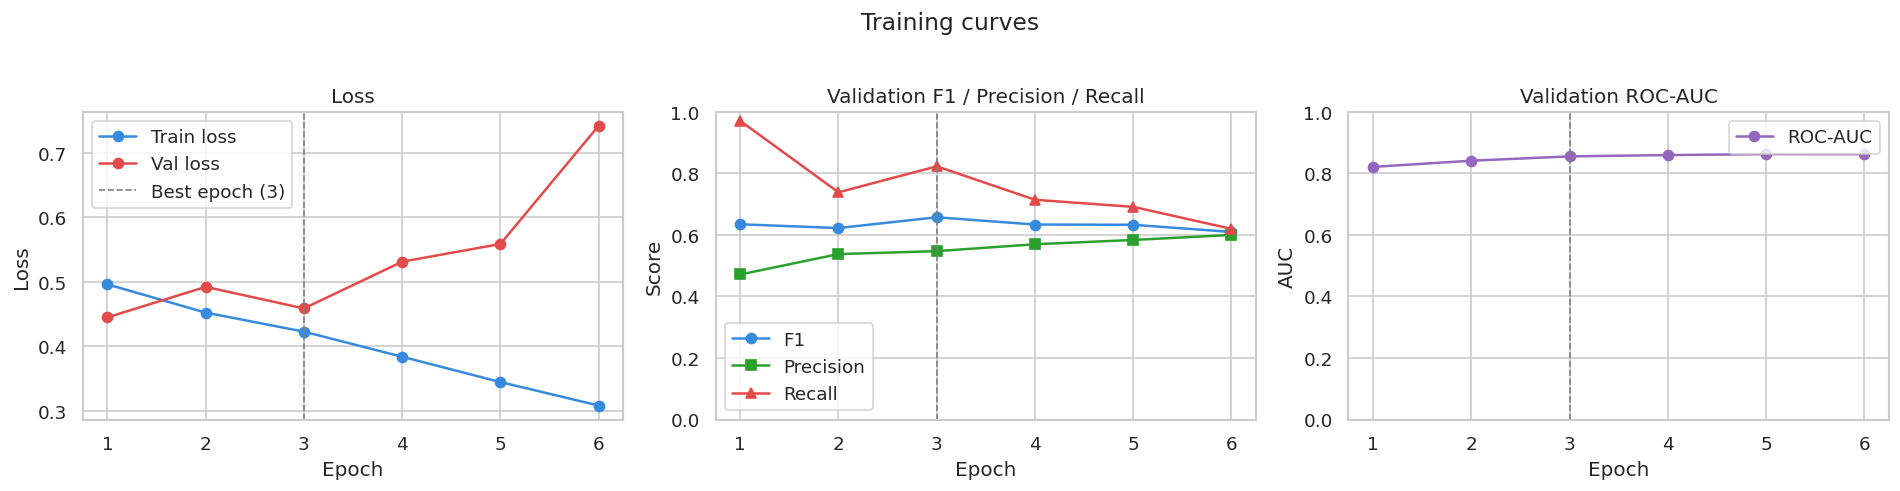

In [30]:
os.makedirs(os.path.join(CONFIG["REPORTS_DIR"], "figures"), exist_ok=True)
FIGURES_DIR = os.path.join(CONFIG["REPORTS_DIR"], "figures")
print(f"Figures will be saved to: {FIGURES_DIR}")

epochs_run = len(history["train_loss"])
x = range(1, epochs_run + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Loss curves ────────────────────────────────────────────────────────
axes[0].plot(x, history["train_loss"], label="Train loss", color="#378ADD", marker="o")
axes[0].plot(x, history["val_loss"],   label="Val loss",   color="#E24B4A", marker="o")
axes[0].axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# ── Plot 2: F1, Precision, Recall ─────────────────────────────────────────────
axes[1].plot(x, history["val_f1"],        label="F1",        color="#378ADD", marker="o")
axes[1].plot(x, history["val_precision"], label="Precision", color="#2CA02C", marker="s")
axes[1].plot(x, history["val_recall"],    label="Recall",    color="#E24B4A", marker="^")
axes[1].axvline(best_epoch, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Validation F1 / Precision / Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()

# ── Plot 3: ROC-AUC ───────────────────────────────────────────────────────────
axes[2].plot(x, history["val_roc_auc"], label="ROC-AUC", color="#9467BD", marker="o")
axes[2].axvline(best_epoch, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Validation ROC-AUC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.suptitle("Training curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "10_training_curves.png"), bbox_inches="tight")
plt.show()

---
## Section 8: Load Best Checkpoint & Evaluate on Test Set

The best checkpoint (highest val F1) is loaded back before running final evaluation.  
The test set was never seen during training or validation — this gives an honest  
estimate of real-world performance.

In [31]:
# Load the best saved checkpoint back into the model.
# This overwrites the weights from the last epoch with the best-epoch weights.

print(f"Loading best checkpoint from epoch {best_epoch}...")

# Re-instantiate and load
best_model = CodeBERTClassifier(
    model_name    = CONFIG["MODEL_SAVE_DIR"],   # loads from saved encoder
    num_labels    = prep_config["num_labels"],
    dropout       = CONFIG["DROPOUT"],
    freeze_layers = 0                           # don't freeze for inference
)

best_model.classifier.load_state_dict(
    torch.load(
        os.path.join(CONFIG["MODEL_SAVE_DIR"], "classifier_head.pt"),
        weights_only=True
    )
)

best_model = best_model.to(DEVICE)
print("Best checkpoint loaded.")

Loading best checkpoint from epoch 3...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   Total parameters    : 124,647,170
   Frozen parameters   : 39,000,576  (bottom 0 encoder layers + embeddings)
   Trainable parameters: 85,646,594  (top 12 encoder layers + head)
Best checkpoint loaded.


In [32]:
# Run final evaluation on the held-out test set.
# This is the only time the test set is touched.

print("Evaluating on test set...\n")

test_metrics = evaluate(best_model, test_loader, loss_fn, DEVICE)

print("=" * 55)
print("  FINAL TEST SET RESULTS")
print("=" * 55)
print(f"  Loss      : {test_metrics['loss']:.4f}")
print(f"  Accuracy  : {test_metrics['accuracy']:.4f}  ({test_metrics['accuracy']*100:.1f}%)")
print(f"  Precision : {test_metrics['precision']:.4f}")
print(f"  Recall    : {test_metrics['recall']:.4f}")
print(f"  F1 Score  : {test_metrics['f1']:.4f}")
print(f"  ROC-AUC   : {test_metrics['roc_auc']:.4f}")
print("=" * 55)

print("\nFull classification report:")
print(classification_report(
    test_metrics["all_labels"],
    test_metrics["all_preds"],
    target_names=["Clean (0)", "Buggy (1)"]
))

Evaluating on test set...



  Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]

  FINAL TEST SET RESULTS
  Loss      : 0.4760
  Accuracy  : 0.7423  (74.2%)
  Precision : 0.5303
  Recall    : 0.8263
  F1 Score  : 0.6460
  ROC-AUC   : 0.8519

Full classification report:
              precision    recall  f1-score   support

   Clean (0)       0.91      0.71      0.80      4256
   Buggy (1)       0.53      0.83      0.65      1693

    accuracy                           0.74      5949
   macro avg       0.72      0.77      0.72      5949
weighted avg       0.80      0.74      0.75      5949



---
## Section 9: Evaluation Plots

Four plots to fully characterize model performance:
1. Confusion matrix — raw counts of TP, TN, FP, FN
2. Normalized confusion matrix — row-wise percentages
3. ROC curve — trade-off between true positive rate and false positive rate
4. Precision-Recall curve — especially informative for imbalanced datasets

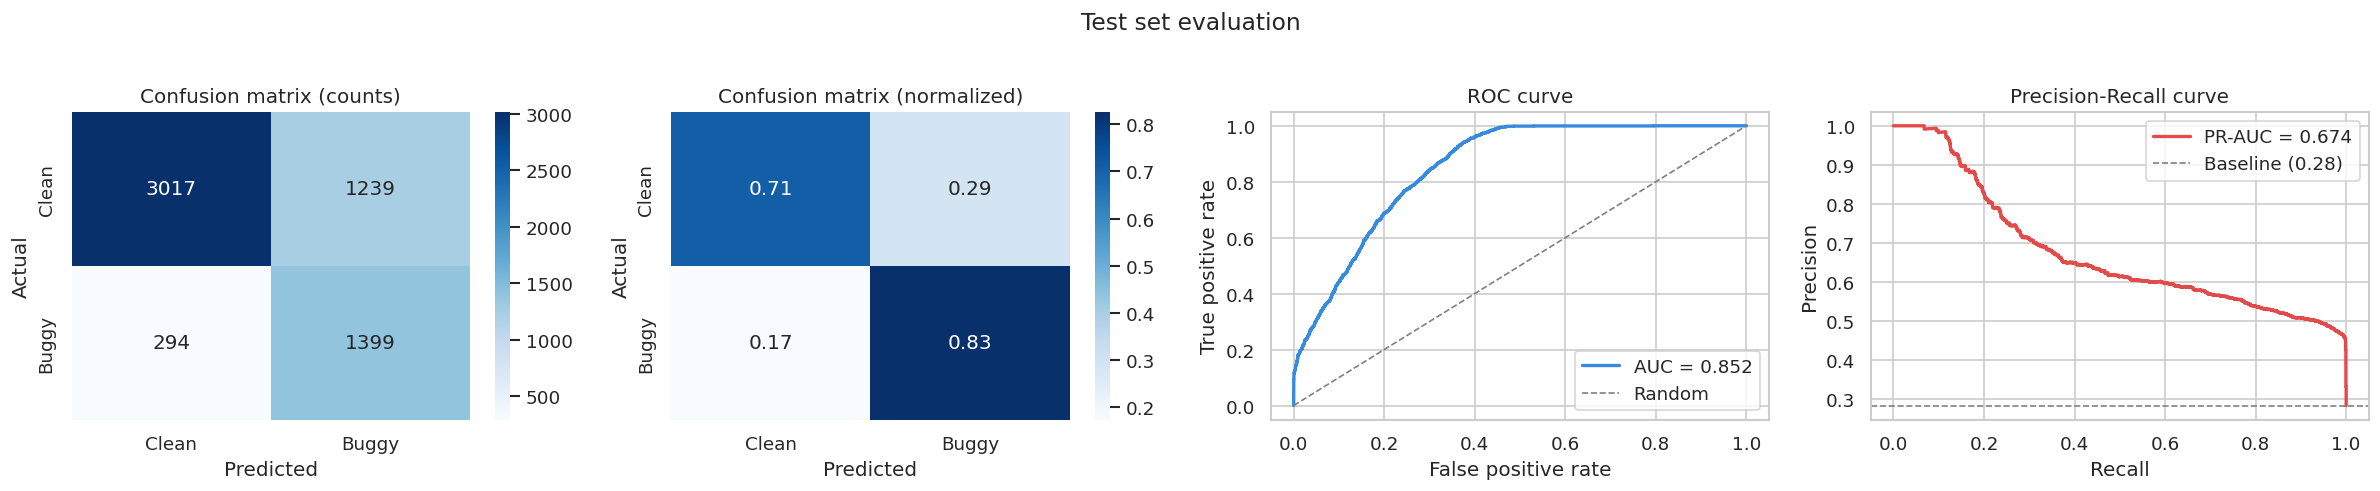

In [33]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# ── Plot 1: Confusion matrix (raw counts) ──────────────────────────────────────
cm = confusion_matrix(test_metrics["all_labels"], test_metrics["all_preds"])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ── Plot 2: Normalized confusion matrix ───────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)
axes[1].set_title("Confusion matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ── Plot 3: ROC curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(test_metrics["all_labels"], test_metrics["all_probs"])
roc_auc_val = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {roc_auc_val:.3f}")
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].legend()

# ── Plot 4: Precision-Recall curve ────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(test_metrics["all_labels"], test_metrics["all_probs"])
pr_auc = auc(rec, prec)
axes[3].plot(rec, prec, color="#E24B4A", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
baseline = test_metrics["all_labels"].mean()
axes[3].axhline(baseline, color="gray", linestyle="--", lw=1,
                label=f"Baseline ({baseline:.2f})")
axes[3].set_title("Precision-Recall curve")
axes[3].set_xlabel("Recall")
axes[3].set_ylabel("Precision")
axes[3].legend()

plt.suptitle("Test set evaluation", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "11_test_evaluation.png"), bbox_inches="tight")
plt.show()

---
## Section 10: Save All Results for Notebook 04

Save the trained model, tokenizer reference, training history, and test metrics  
so Notebook 04 (Evaluation & Explainability) can load everything without retraining.

In [34]:
# Save training history and test metrics to a single results file.
# Notebook 04 loads this to display results and run explainability.

results = {
    "history"        : history,
    "test_metrics"   : {k: v for k, v in test_metrics.items()
                        if k not in ("all_preds", "all_labels", "all_probs")},
    "test_preds"     : test_metrics["all_preds"],
    "test_labels"    : test_metrics["all_labels"],
    "test_probs"     : test_metrics["all_probs"],
    "best_epoch"     : best_epoch,
    "best_val_f1"    : best_val_f1,
    "config"         : CONFIG,
    "prep_config"    : prep_config,
    "class_weights"  : class_weights.tolist()
}

results_path = os.path.join(CONFIG["REPORTS_DIR"], "training_results.pkl")
with open(results_path, "wb") as f:
    pickle.dump(results, f)

print(f"Training results saved -> {results_path}")

Training results saved -> /content/drive/MyDrive/code_review_project/reports/training_results.pkl


In [35]:
# Save the tokenizer alongside the model so Notebook 04 loads it from disk
# without re-downloading from HuggingFace.

# Load directly from HuggingFace (since local tokenizer path fails on Colab)
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
tokenizer.save_pretrained(CONFIG["MODEL_SAVE_DIR"])
print(f"Tokenizer saved -> {CONFIG['MODEL_SAVE_DIR']}")

# Final file inventory
print("\nAll saved files:")
for root, dirs, files in os.walk(CONFIG["MODEL_SAVE_DIR"]):
    for f in files:
        path = os.path.join(root, f)
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"   {path:<60} {size_mb:>6.1f} MB")

print()
for root, dirs, files in os.walk(CONFIG["REPORTS_DIR"]):
    for f in files:
        path = os.path.join(root, f)
        print(f"   {path}")

Tokenizer saved -> /content/drive/MyDrive/code_review_project/models/codebert_classifier/

All saved files:
   /content/drive/MyDrive/code_review_project/models/codebert_classifier/config.json    0.0 MB
   /content/drive/MyDrive/code_review_project/models/codebert_classifier/model.safetensors  475.5 MB
   /content/drive/MyDrive/code_review_project/models/codebert_classifier/classifier_head.pt    0.0 MB
   /content/drive/MyDrive/code_review_project/models/codebert_classifier/dropout.pt    0.0 MB
   /content/drive/MyDrive/code_review_project/models/codebert_classifier/tokenizer_config.json    0.0 MB
   /content/drive/MyDrive/code_review_project/models/codebert_classifier/tokenizer.json    3.4 MB

   /content/drive/MyDrive/code_review_project/reports/training_results.pkl
   /content/drive/MyDrive/code_review_project/reports/figures/10_training_curves.png
   /content/drive/MyDrive/code_review_project/reports/figures/11_test_evaluation.png


In [36]:
print("""
═══════════════════════════════════════════════════════════
         NOTEBOOK 03 COMPLETE
═══════════════════════════════════════════════════════════
  Next -> Notebook 04: Evaluation & Explainability
═══════════════════════════════════════════════════════════
""")

print(f"  Best epoch      : {best_epoch}")
print(f"  Best val F1     : {best_val_f1:.4f}")
print(f"  Test accuracy   : {test_metrics['accuracy']:.4f}")
print(f"  Test F1         : {test_metrics['f1']:.4f}")
print(f"  Test ROC-AUC    : {test_metrics['roc_auc']:.4f}")


═══════════════════════════════════════════════════════════
         NOTEBOOK 03 COMPLETE
═══════════════════════════════════════════════════════════
  Next -> Notebook 04: Evaluation & Explainability
═══════════════════════════════════════════════════════════

  Best epoch      : 3
  Best val F1     : 0.6572
  Test accuracy   : 0.7423
  Test F1         : 0.6460
  Test ROC-AUC    : 0.8519
